In [3]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv('insurance.csv')

In [5]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA

In [6]:
df.shape

(1338, 7)

In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

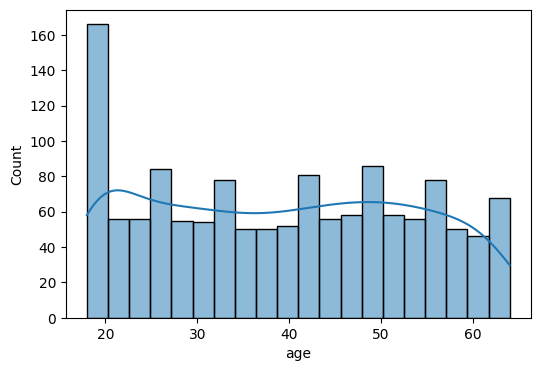

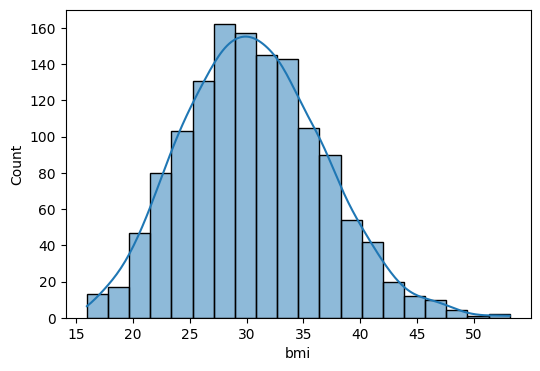

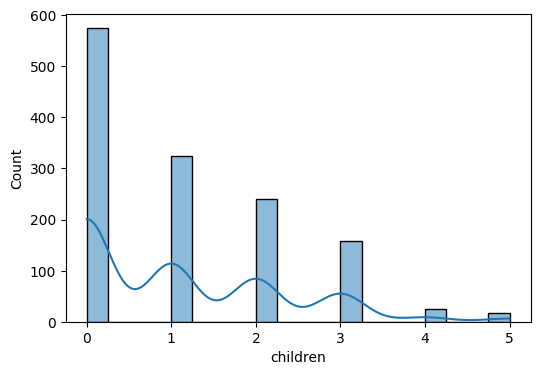

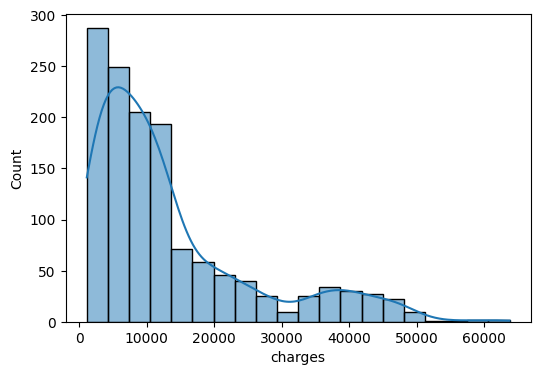

In [11]:
numeric_col=['age','bmi','children','charges']
for col in numeric_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

<Axes: xlabel='children', ylabel='count'>

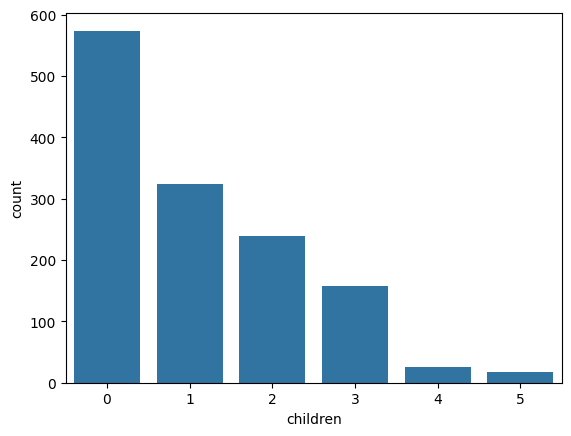

In [12]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

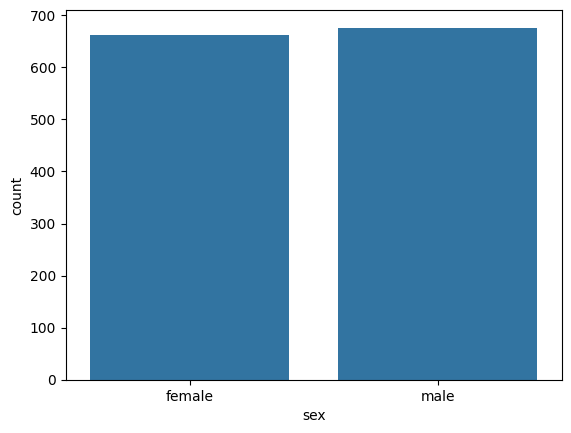

In [13]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

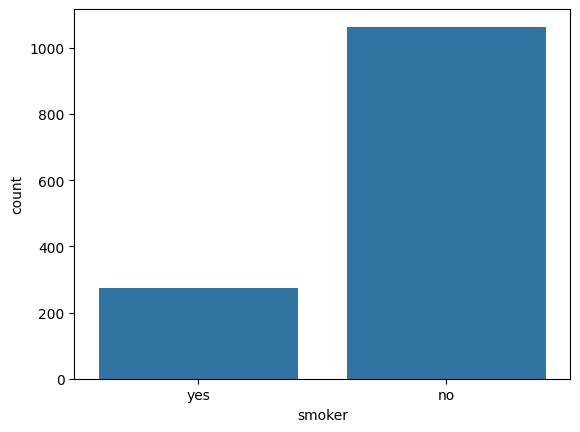

In [14]:
sns.countplot(x=df['smoker'])

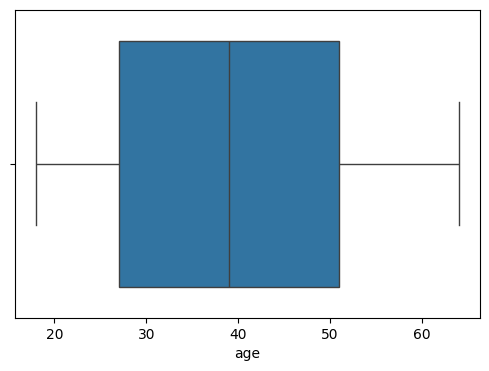

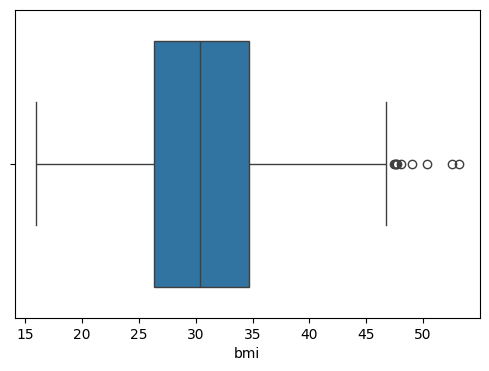

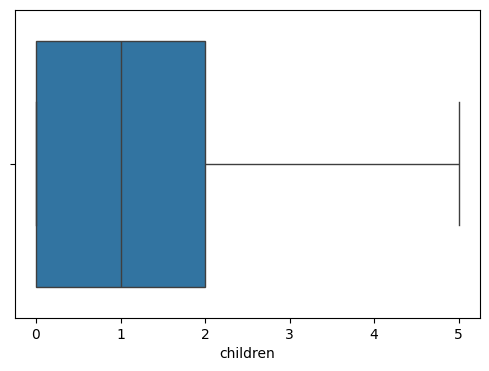

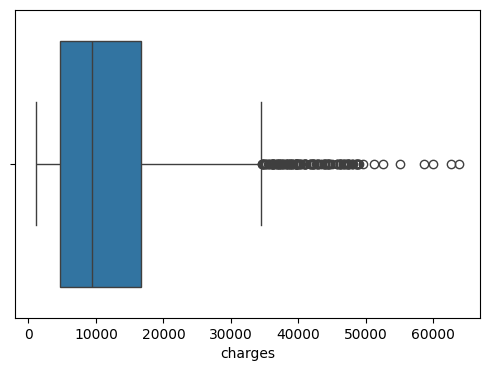

In [15]:
for col in numeric_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

<Axes: >

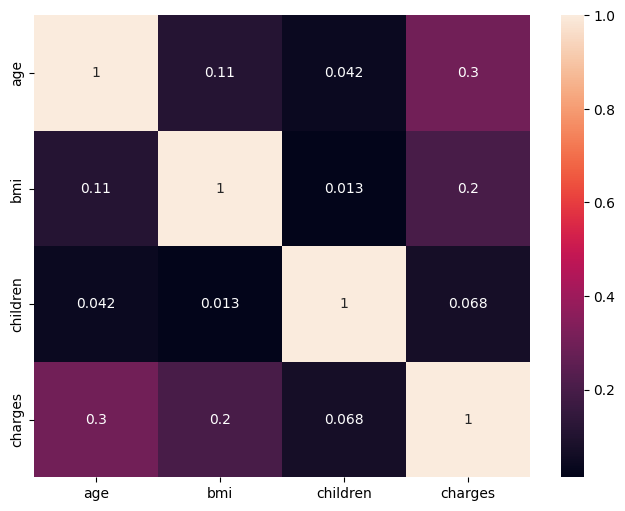

In [16]:
#correlation used only numeric value
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Cleaning And Preprocessing

In [17]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [18]:
#there is no missing value so move to remove duplicate value

In [19]:
df.shape

(1338, 7)

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df.shape

(1337, 7)

In [22]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [23]:
#we have to convert string value into numeric (encoding)

In [24]:
df['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [25]:
df['sex']=df['sex'].map({'male':0,'female':1})

In [26]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [27]:
df['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [28]:
df['smoker']=df['smoker'].map({'no':0,'yes':1})

In [29]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [30]:
df.rename(columns={'sex':'is_female','smoker':'is_smoker'},inplace=True)

In [31]:
df.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [32]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [33]:
df=pd.get_dummies(df,columns=['region'])

In [34]:
df.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


In [35]:
df=df.astype(int)

In [36]:
df

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0
1334,18,1,31,0,0,2205,1,0,0,0
1335,18,1,36,0,0,1629,0,0,1,0
1336,21,1,25,0,0,2007,0,0,0,1


# Feature Engineering and Extraction

In [37]:
#add columns from bmi variable

In [39]:
df["bmi_category"]=pd.cut(
    df['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['underweight','normal','overweight','obese']
    )

In [40]:
df.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,0,1,overweight
1,18,0,33,1,0,1725,0,0,1,0,obese
2,28,0,33,3,0,4449,0,0,1,0,obese
3,33,0,22,0,0,21984,0,1,0,0,normal
4,32,0,28,0,0,3866,0,1,0,0,overweight


In [41]:
df=pd.get_dummies(df,columns=['bmi_category'])

In [43]:
df.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,0,1,False,False,True,False
1,18,0,33,1,0,1725,0,0,1,0,False,False,False,True
2,28,0,33,3,0,4449,0,0,1,0,False,False,False,True
3,33,0,22,0,0,21984,0,1,0,0,False,True,False,False
4,32,0,28,0,0,3866,0,1,0,0,False,False,True,False


In [46]:
df=df.astype(int)
df.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0


In [47]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']
scaler=StandardScaler()

df[cols]=scaler.fit_transform(df[cols])

In [48]:
df.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,0,1,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,0,1,0,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,0,1,0,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,1,0,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,1,0,0,0,0,1,0


In [49]:
#feature axtraction (check the correlation against by target varible )


In [50]:
from scipy.stats import pearsonr
#pearsonr correlation calculation
#list of feature to check against target

selected_features=['age', 'is_female', 'bmi', 'children', 'is_smoker','region_northeast',
       'region_northwest', 'region_southeast', 'region_southwest','bmi_category_underweight',
       'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese']

correlations={
    feature:pearsonr(df[feature],df['charges'])[0]
    for feature in selected_features
}
#convet correlation into dataframe
correlation_df=pd.DataFrame(list(correlations.items()),columns=['Feature','pearsonr correlation'])
correlation_df.sort_values(by='pearsonr correlation',ascending=False)

,Feature,pearsonr correlation
4,is_smoker,0.787234
0,age,0.298309
12,bmi_category_obese,0.200348
2,bmi,0.196236
7,region_southeast,0.073577
3,children,0.067390
5,region_northeast,0.005946
6,region_northwest,-0.038695
8,region_southwest,-0.043637
9,bmi_category_underweight,-0.050599


In [51]:
#correlation with categorical feature

In [52]:
from scipy.stats import chi2_contingency

categorical_feature=['is_female','is_smoker','region_northeast',
                    'region_southeast','region_northwest','region_southwest',
                      'bmi_category_underweight','bmi_category_obese','bmi_category_normal','bmi_category_overweight'
                    ]


alpha=0.05
df['charges_bin']=pd.qcut(df['charges'],q=4,labels=False)
chi2_results={}

for col in categorical_feature:
    contingency=pd.crosstab(df[col],df['charges_bin'])
    chi2_stat,p_val,_,_=chi2_contingency(contingency)
    decision='keep feature' if p_val < alpha else 'drop feature'
    chi2_results[col]={
        'chi2_statistic':chi2_stat,
        'p_value':p_val,
        'decision':decision
    }

chi2_df=pd.DataFrame(chi2_results).T
chi2_df=chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,decision
is_smoker,848.219178,0.0,keep feature
region_southeast,15.998167,0.001135,keep feature
is_female,10.258784,0.01649,keep feature
bmi_category_obese,8.515711,0.036473,keep feature
region_northeast,6.438442,0.092122,drop feature
region_southwest,5.091893,0.165191,drop feature
bmi_category_overweight,4.25149,0.235557,drop feature
bmi_category_normal,3.708088,0.29476,drop feature
bmi_category_underweight,3.37403,0.337471,drop feature
region_northwest,1.13424,0.768815,drop feature


In [53]:
#final df
final_df=df[['age','is_female','bmi','children','is_smoker','charges','region_southeast','bmi_category_obese']]
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0
